# Marketing Campaign Performance Insights

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Dataset loading
url = "https://raw.githubusercontent.com/ArchanaInsights/Datasets/main/marketing_campaign.csv"
df = pd.read_csv(url)

## Descriptive Analysis

In [5]:
# First few rows
df.head()

,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,TechCorp,Email,Women 25-34,30 days,Facebook,5.294194,9344,62.94,Houston,English,3045,67836,5,Tech Enthusiasts,01-01-2023
1,2,Innovate Industries,Influencer,Women 35-44,45 days,Google Ads,3.326375,8783,10.67,"Washington, D.C.",German,1944,66361,4,Foodies,01-01-2023
2,3,NexGen Systems,Social Media,Women 25-34,45 days,Instagram,4.056375,9111,73.20,Miami,Spanish,3156,86240,8,Fashionistas,01-01-2023
3,4,Innovate Industries,Email,Women 25-34,45 days,Instagram,4.496375,7420,60.92,Seattle,Spanish,2388,58251,6,Foodies,01-01-2023
4,5,Data Tech Solutions,Influencer,Men 25-34,30 days,Google Ads,4.405930,2146,138.82,Chicago,English,1025,34407,5,Tech Enthusiasts,01-01-2023


In [6]:
# Rows and Columns
df.shape

(22029, 16)

In [7]:
# concise summary of the dataset, including the data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22029 entries, 0 to 22028
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       22029 non-null  int64  
 1   Company           22029 non-null  object 
 2   Campaign_Type     22029 non-null  object 
 3   Target_Audience   22029 non-null  object 
 4   Duration          22029 non-null  object 
 5   Channel_Used      22029 non-null  object 
 6   Conversion_Rate   22029 non-null  float64
 7   Acquisition_Cost  22029 non-null  int64  
 8   ROI               22029 non-null  float64
 9   Location          22029 non-null  object 
 10  Language          22029 non-null  object 
 11  Clicks            22029 non-null  int64  
 12  Impressions       22029 non-null  int64  
 13  Engagement_Score  22029 non-null  int64  
 14  Customer_Segment  22029 non-null  object 
 15  Date              22029 non-null  object 
dtypes: float64(2), int64(5), object(9)
memor

In [8]:
# Descriptive statistics
df.describe()

,Campaign_ID,Conversion_Rate,Acquisition_Cost,ROI,Clicks,Impressions,Engagement_Score
count,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000,22029.000000
mean,11015.000000,4.757232,5522.740842,182.863648,2223.807572,50610.402787,6.582323
std,6359.368876,0.960393,2597.666260,301.619721,1394.166380,28542.979123,1.458804
min,1.000000,2.015723,1000.000000,-98.300000,30.000000,1001.000000,4.000000
25%,5508.000000,4.130705,3286.000000,-4.080000,1067.000000,25804.000000,5.000000
50%,11015.000000,4.761527,5525.000000,93.650000,2088.000000,50858.000000,7.000000
75%,16522.000000,5.429335,7766.000000,247.310000,3212.000000,75165.000000,8.000000
max,22029.000000,7.469907,9999.000000,3109.790000,6887.000000,99999.000000,9.000000


## Data Exploration

In [9]:
print("Unique Campaigns:", df['Campaign_ID'].nunique())

Unique Campaigns: 22029


In [10]:
print("Unique Locations:", df['Location'].unique())
print("Unique Customer Segments:", df['Customer_Segment'].unique())


Unique Locations: ['Houston' 'Washington, D.C.' 'Miami' 'Seattle' 'Chicago' 'Los Angeles'
 'Atlanta' 'Dallas' 'New York' 'San Francisco']
Unique Customer Segments: ['Tech Enthusiasts' 'Foodies' 'Fashionistas' 'Outdoor Adventurers'
 'Health & Wellness']


In [11]:
campaign_type_counts = df['Campaign_Type'].value_counts()
channel_used_counts = df['Channel_Used'].value_counts()
print("Campaign Type Counts:\n", campaign_type_counts)
print("\nChannel Used Counts:\n", channel_used_counts)


Campaign Type Counts:
 Campaign_Type
Display         4450
Search          4441
Social Media    4412
Email           4388
Influencer      4338
Name: count, dtype: int64

Channel Used Counts:
 Channel_Used
Facebook      3742
Google Ads    3694
Website       3688
Instagram     3649
YouTube       3632
Email         3624
Name: count, dtype: int64


## Exploratory Data Analysis (EDA) and Visualization

### Campaign Performance

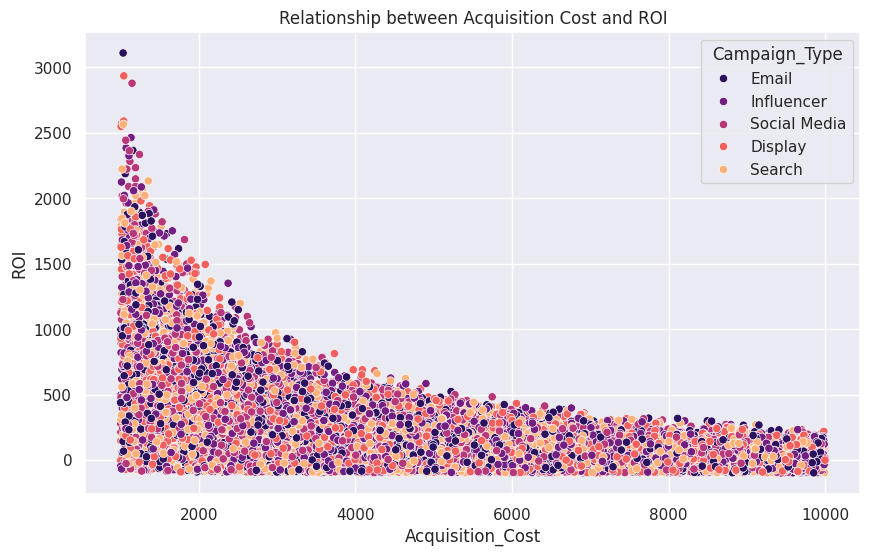

In [120]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Acquisition_Cost', y='ROI', data=df, hue='Campaign_Type',palette='magma')
plt.title("Relationship between Acquisition Cost and ROI")
plt.show()

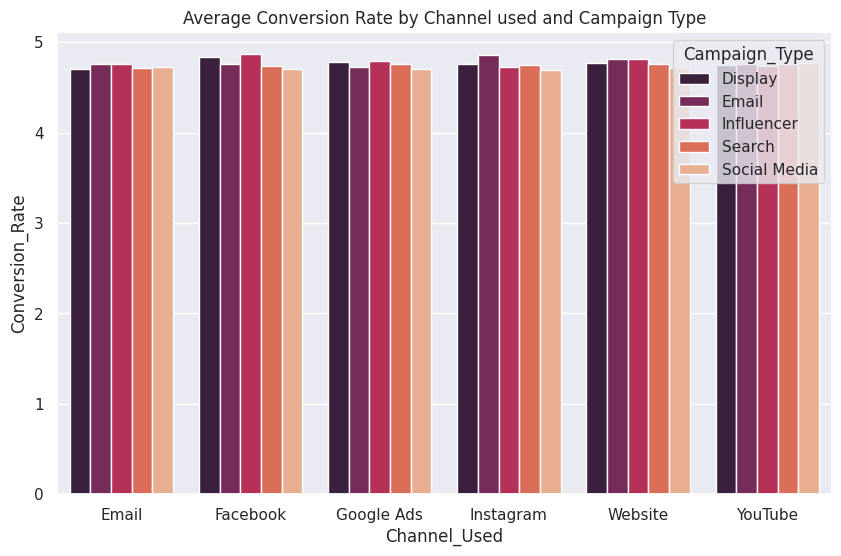

In [105]:
avg_conv = df.groupby(['Channel_Used','Campaign_Type'])['Conversion_Rate'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=avg_conv, x='Channel_Used', y='Conversion_Rate', hue='Campaign_Type',palette='rocket')
plt.title("Average Conversion Rate by Channel used and Campaign Type")
plt.show()

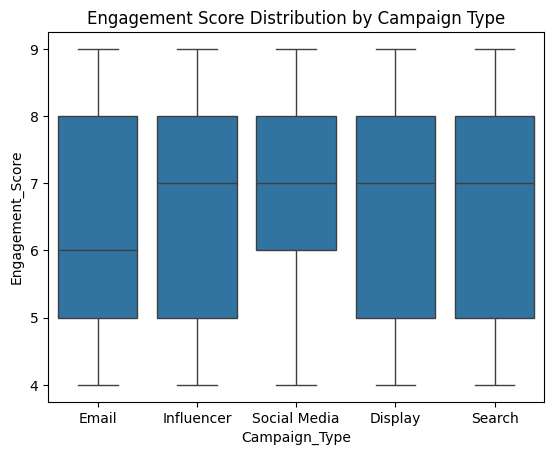

In [28]:
sns.boxplot(x='Campaign_Type', y='Engagement_Score', data=df)
plt.title("Engagement Score Distribution by Campaign Type")
plt.show()


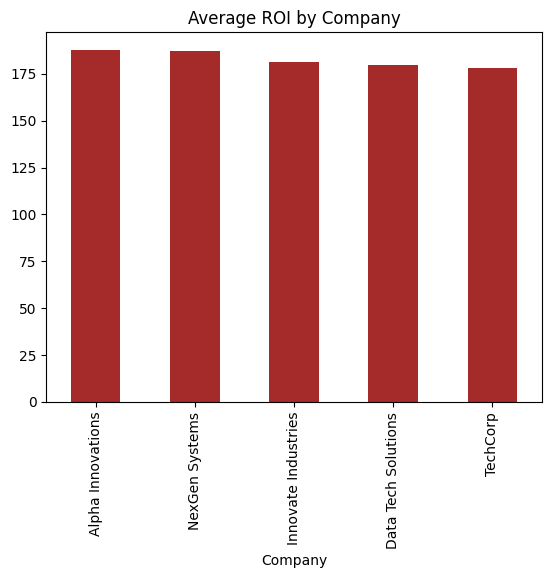

In [46]:
roi_company = df.groupby('Company')['ROI'].mean().sort_values(ascending=False)
roi_company.plot(kind='bar',color='brown', title='Average ROI by Company')
plt.show()


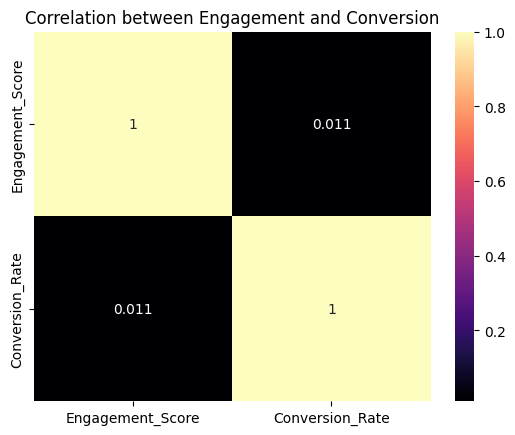

In [38]:
sns.heatmap(df[['Engagement_Score','Conversion_Rate']].corr(), annot=True, cmap='magma')
plt.title("Correlation between Engagement and Conversion")
plt.show()


### Customer Segmentation

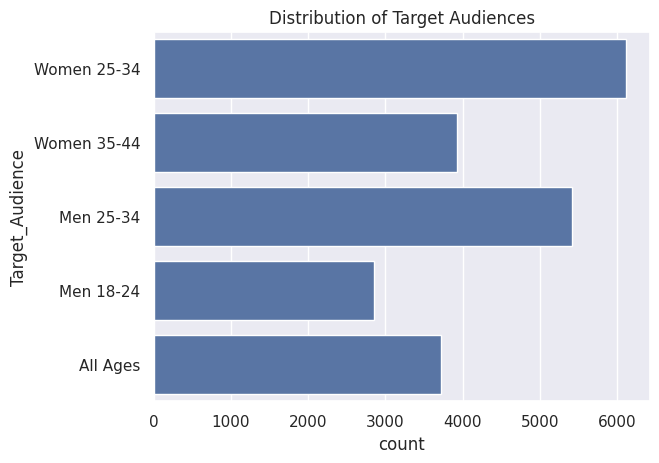

In [97]:
sns.countplot(y='Target_Audience', data=df)
plt.title("Distribution of Target Audiences")
plt.show()

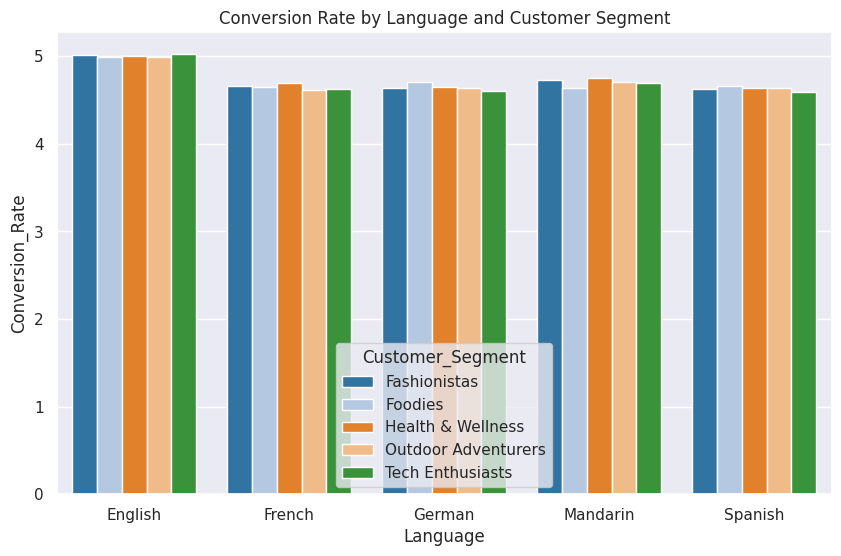

In [106]:
conv_lang_seg = df.groupby(['Language','Customer_Segment'])['Conversion_Rate'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=conv_lang_seg, x='Language', y='Conversion_Rate', hue='Customer_Segment',palette='tab20')
plt.title("Conversion Rate by Language and Customer Segment")
plt.show()


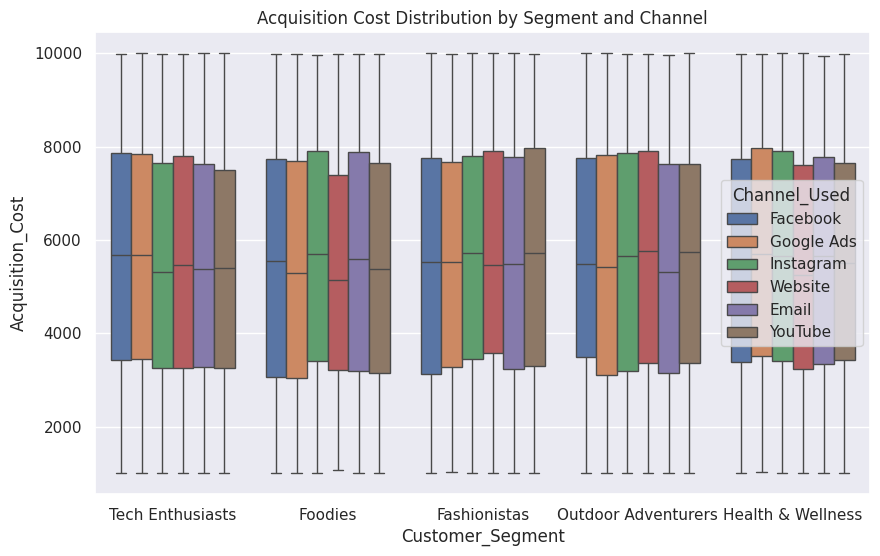

In [107]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Customer_Segment', y='Acquisition_Cost', hue='Channel_Used', data=df)
plt.title("Acquisition Cost Distribution by Segment and Channel")
plt.show()



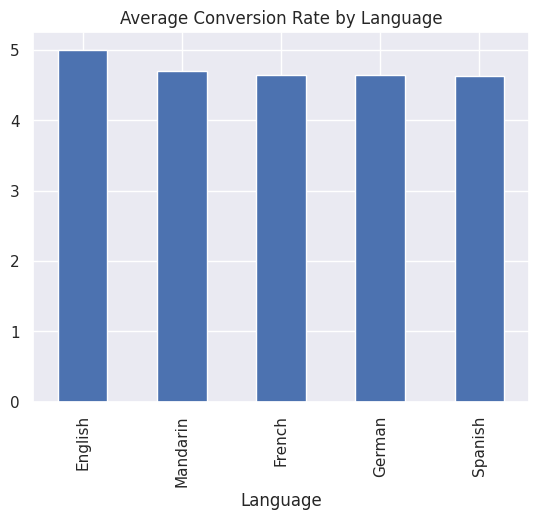

In [110]:
lang_conv = df.groupby('Language')['Conversion_Rate'].mean().sort_values(ascending=False)
lang_conv.plot(kind='bar', title="Average Conversion Rate by Language")
plt.show()


### Channel Effectivenes

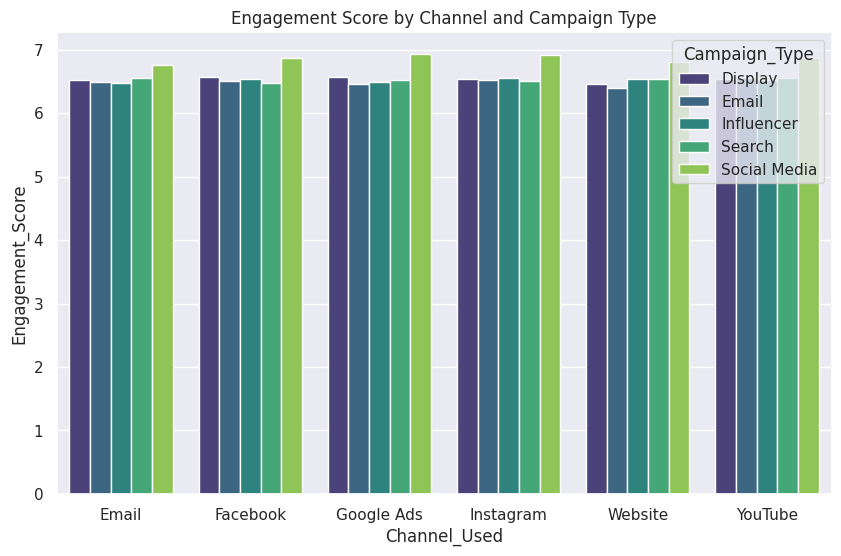

In [114]:
eng_channel = df.groupby(['Channel_Used','Campaign_Type'])['Engagement_Score'].mean().reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=eng_channel, x='Channel_Used', y='Engagement_Score', hue='Campaign_Type',palette='viridis')
plt.title("Engagement Score by Channel and Campaign Type")
plt.show()


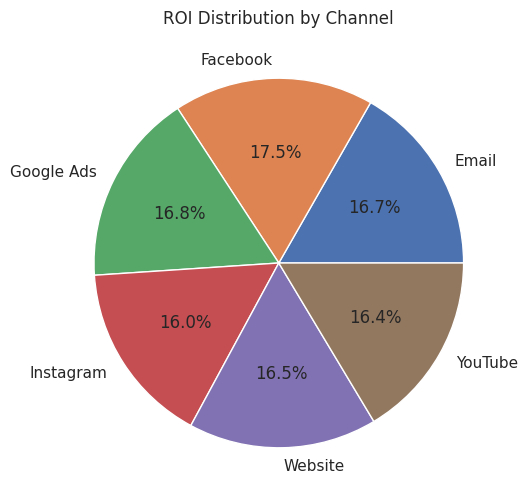

In [148]:
roi_channel = df.groupby('Channel_Used')['ROI'].sum()
plt.figure(figsize=(10,6))
roi_channel.plot(kind='pie', autopct='%1.1f%%', title="ROI Distribution by Channel")
plt.ylabel("")
plt.show()

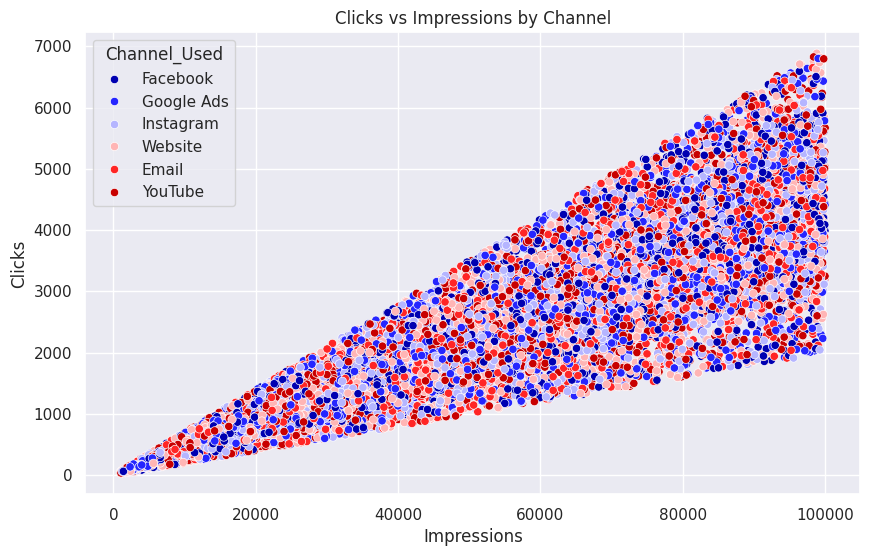

In [130]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Impressions', y='Clicks', hue='Channel_Used', data=df,palette='seismic')
plt.title("Clicks vs Impressions by Channel")
plt.show()

### Time-Based Analysis


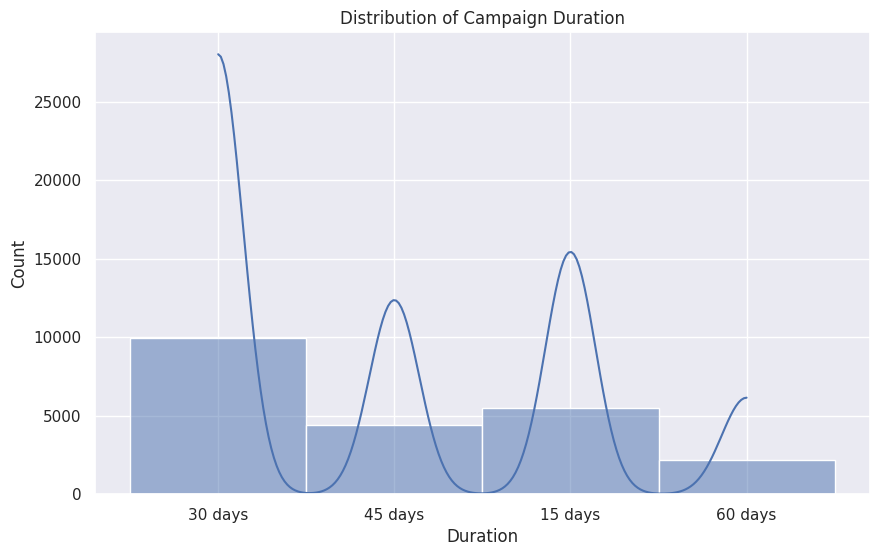

In [133]:
plt.figure(figsize=(10,6))
sns.histplot(df['Duration'], bins=20, kde=True)
plt.title("Distribution of Campaign Duration")
plt.show()


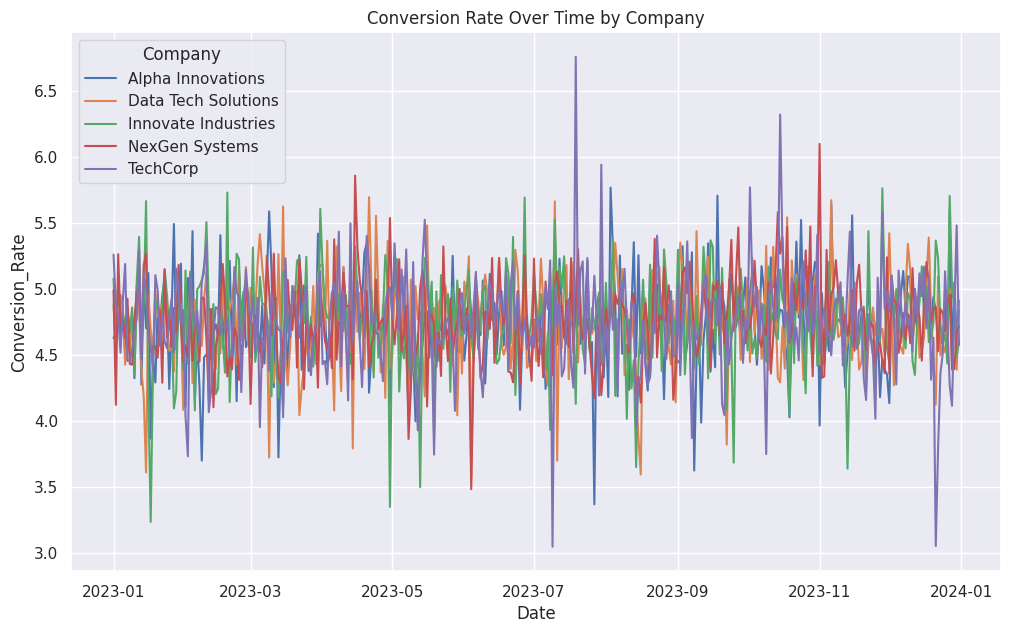

In [145]:
df['Date'] = pd.to_datetime(df['Date'], format="%d-%m-%Y")
plt.figure(figsize=(12,7))
conv_time = df.groupby(['Date','Company'])['Conversion_Rate'].mean().reset_index()
sns.lineplot(data=conv_time, x='Date', y='Conversion_Rate', hue='Company',markers=10)
plt.title("Conversion Rate Over Time by Company")
plt.show()

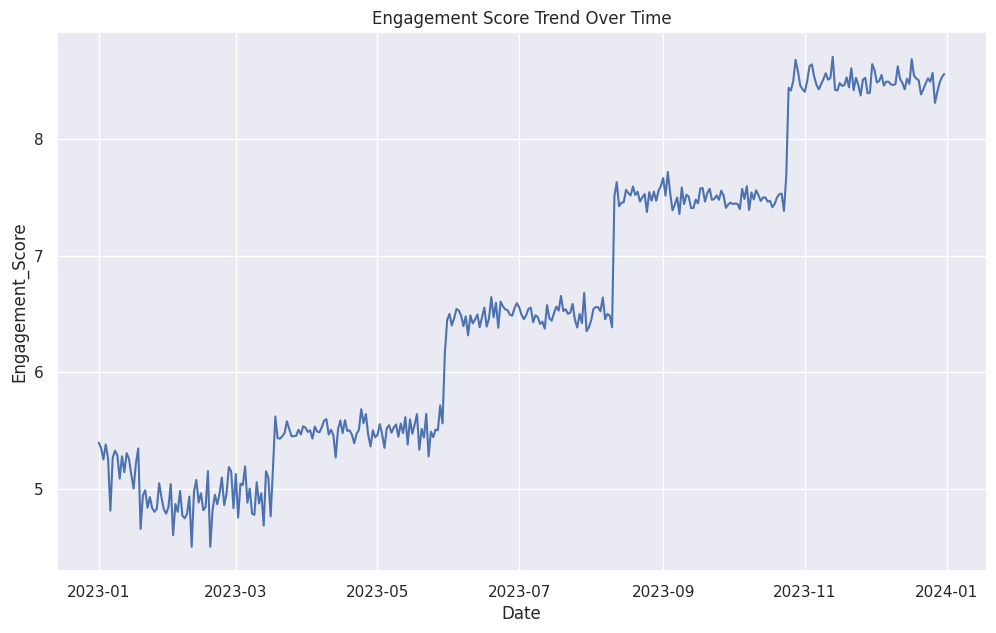

In [147]:
eng_time = df.groupby('Date')['Engagement_Score'].mean().reset_index()
plt.figure(figsize=(12,7))
sns.lineplot(data=eng_time, x='Date', y='Engagement_Score')
plt.title("Engagement Score Trend Over Time")
plt.show()

### Geographic Analysis

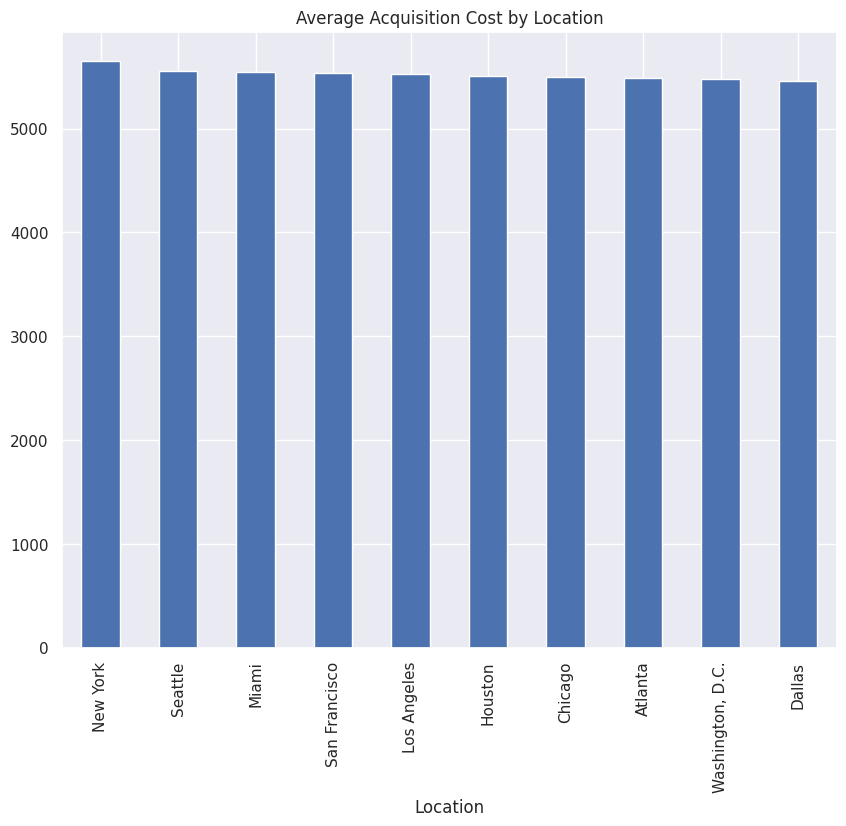

In [162]:
plt.figure(figsize=(10,8))
loc_cost = df.groupby('Location')['Acquisition_Cost'].mean().sort_values(ascending=False)
loc_cost.plot(kind='bar', title='Average Acquisition Cost by Location')
plt.show()

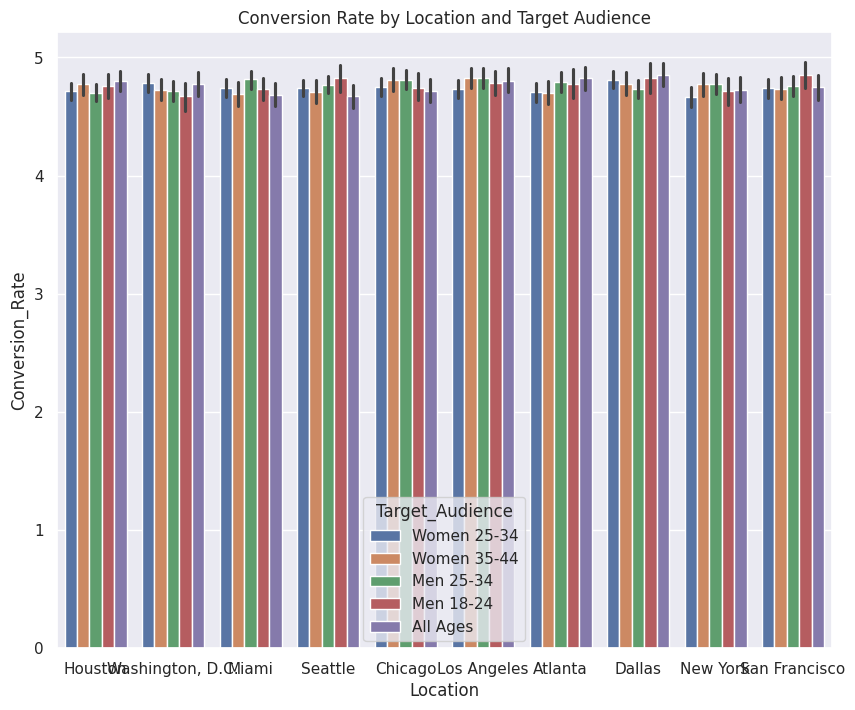

In [161]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df, x='Location', y='Conversion_Rate', hue='Target_Audience')
plt.title("Conversion Rate by Location and Target Audience")
plt.show()


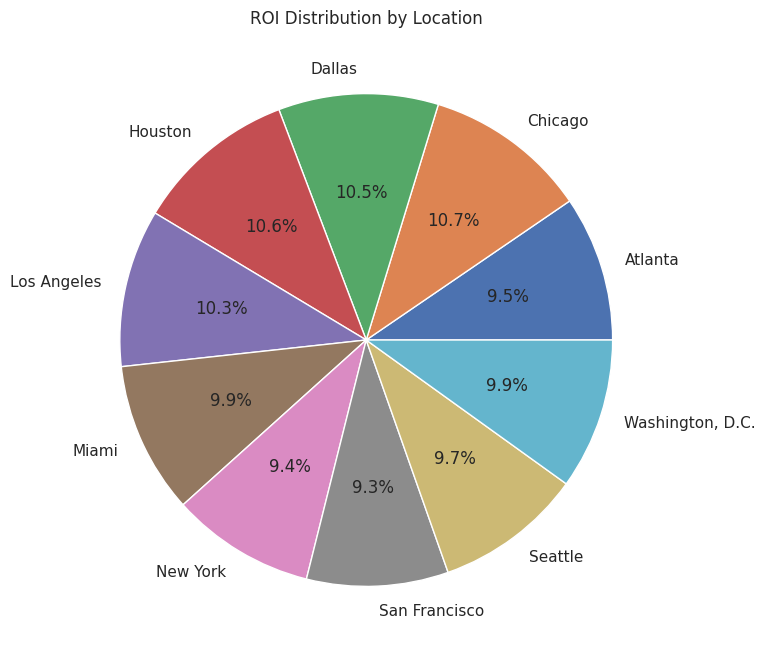

In [164]:
plt.figure(figsize=(10,8))
roi_loc = df.groupby('Location')['ROI'].sum()
roi_loc.plot(kind='pie', autopct='%1.1f%%', title="ROI Distribution by Location")
plt.ylabel("")
plt.show()
